# Lab 2 — Biological Binary Classification, Logistic Regression, and Regularization

Author: Dario Righelli

This notebook is designed for a Master's degree course in Quantitative and Computational Biology.

In Lab 1, we used a real biological data matrix to study linear regression, the Mean Squared Error (MSE), and Gradient Descent (GD). In this lab, we move from **regression** to **binary classification**.

We use a real single-cell ribonucleic acid sequencing (single-cell RNA-seq) dataset and train a logistic regression model to classify cells as:

- `1`: neuronal cell
- `0`: non-neuronal cell

The model uses gene expression features.

## Expected input file

This notebook expects a preprocessed comma-separated values (CSV) file called:

```text
zeisel_neuron_classification.csv
```

The expected structure is:

```text
cell_id
cell_type
label
gene_001__...
gene_002__...
...
```

where `label = 1` means neuronal and `label = 0` means non-neuronal.

## Matrix orientation reminder

In many bioinformatics workflows, expression matrices are stored as:

```text
rows = genes
columns = cells
```

In machine learning, we usually need:

```text
rows = cells
columns = features
```

Therefore, the expression matrix is often transposed before being used as a machine learning input matrix.

## Learning goals

By the end of this notebook, you should be able to:

- load a biological classification dataset
- represent a gene expression matrix in machine learning format
- compute linear classification scores
- use the sigmoid function to convert scores into probabilities
- implement logistic regression from scratch using NumPy
- compute Binary Cross-Entropy (BCE) loss
- train logistic regression with Gradient Descent (GD)
- evaluate a binary classifier
- understand L2 regularization
- inspect coefficients in a biological context


In [1]:
# Section 0 - Setup
# pandas is used for table import.
# NumPy is used for numerical computation.
# Matplotlib is used for visualization.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## Section 1 — Load the biological classification dataset

The target is binary:

- `1`: neuronal cell
- `0`: non-neuronal cell

This is different from Lab 1, where the target was continuous. Here, the goal is to assign each cell to one of two biological classes.


In [2]:
# Section 1 - Load the dataset

data_path = Path("zeisel_neuron_classification.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find 'zeisel_neuron_classification.csv'. "
        "Place it in the same directory as this notebook or update data_path."
    )

data = pd.read_csv(data_path)

print("Dataset shape:", data.shape)
display(data.head())

required_columns = ["cell_id", "cell_type", "label"]
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

gene_columns = [col for col in data.columns if col.startswith("gene_")]
print("Number of gene expression features:", len(gene_columns))
print("First 10 gene feature columns:")
print(gene_columns[:10])

X_raw = data[gene_columns].to_numpy(dtype=float)
y = data["label"].to_numpy(dtype=int)

print("\nShape of X_raw:", X_raw.shape)
print("Shape of y:", y.shape)
print("\nUnique labels and counts:")
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f"label {label}: {count} cells")


Dataset shape: (3005, 103)


,cell_id,cell_type,label,gene_001__Plp1,gene_002__Trf,gene_003__Mal,gene_004__Apod,gene_005__Mog,gene_006__Mbp,gene_007__Car2,...,gene_091__Pdlim2,gene_092__Eno2,gene_093__Vsnl1,gene_094__Ncdn,gene_095__Scn2a1,gene_096__Rasgrp1,gene_097__Gstp1,gene_098__Npy,gene_099__Rgs4,gene_100__Gabra1
0,1772071015_C02,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.911539,4.302407,2.811624,3.174352,1.878092,3.911539,6.858766,0.000000,4.147656
1,1772071017_G12,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,4.410823,5.771367,2.639523,3.434108,0.725878,0.725878,0.000000,3.248047,5.017366
2,1772071017_A05,interneurons,1,0.544784,0.0,0.0,0.0,0.0,0.0,1.719845,...,0.0,3.210769,3.742831,2.978567,3.586314,0.000000,1.907972,5.808803,0.000000,3.791445
3,1772071014_B06,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,4.054166,6.037357,2.326120,3.434741,1.225388,2.856957,0.000000,0.000000,5.935889
4,1772067065_H06,interneurons,1,0.756446,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.951942,4.569715,2.703675,4.242025,0.000000,2.152709,0.000000,0.000000,5.811109


Number of gene expression features: 100
First 10 gene feature columns:
['gene_001__Plp1', 'gene_002__Trf', 'gene_003__Mal', 'gene_004__Apod', 'gene_005__Mog', 'gene_006__Mbp', 'gene_007__Car2', 'gene_008__Meg3', 'gene_009__Cnp', 'gene_010__Enpp2']

Shape of X_raw: (3005, 100)
Shape of y: (3005,)

Unique labels and counts:
label 0: 1377 cells
label 1: 1628 cells


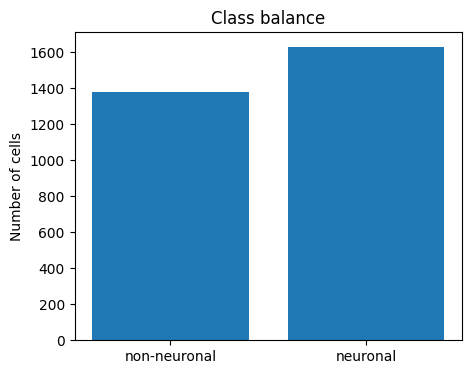

In [3]:
# Section 1 - Visualize class balance

labels = ["non-neuronal", "neuronal"]
counts = [np.sum(y == 0), np.sum(y == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.ylabel("Number of cells")
plt.title("Class balance")
plt.show()


The class balance plot tells us whether the two biological groups are equally represented. If one class is much larger than the other, accuracy alone can be misleading.

### Exercises for Section 1

**Exercise 1.1** Print the number of cells and the number of gene features.

**Exercise 1.2** Print how many cells are neuronal and how many are non-neuronal.

**Exercise 1.3** Answer in words: what does one row of `X_raw` represent?

**Exercise 1.4** Answer in words: what does one column of `X_raw` represent?


In [ ]:
# Exercises for Section 1

# Ex 1.1
display(data.head())
gene_feats = [f for f in data.columns if f.startswith("gene_")]
print(f"Number of cells: {data.shape[0]}\nNumber of gene features:{len(gene_feats)}")

# Ex 1.2
print()
print(data["label"].value_counts())

# Ex 1.3
"""Each row of X_raw holds the gene expression profile of a cell (RNA counts),
allowing for a comparison of entire gene expression profiles across all cells (rows)"""

# Ex 1.4
"""Each column of X_raw holds the log RNA counts transcribed from a given gene of that column,
allowing for a comparison of that gene's expression profile across all cells."""

## Section 2 — Data exploration and feature scaling

The file contains selected variable genes. Each gene is a feature. Because gene expression features can have different scales, we standardize them before training.

For each feature, standardization computes:

$$
x_{std} = \frac{x - \mu}{\sigma}
$$

where $\mu$ is the feature mean and $\sigma$ is the feature standard deviation.


In [4]:
# Section 2 - Basic feature summaries

feature_means = X_raw.mean(axis=0)
feature_stds = X_raw.std(axis=0)

print("Mean of the first 5 gene features:")
print(feature_means[:5])
print("\nStandard deviation of the first 5 gene features:")
print(feature_stds[:5])


Mean of the first 5 gene features:
[3.88112772 2.2605409  2.29886397 1.88782965 1.81309992]

Standard deviation of the first 5 gene features:
[3.86975498 3.12250719 2.99514857 2.7621676  2.66782099]


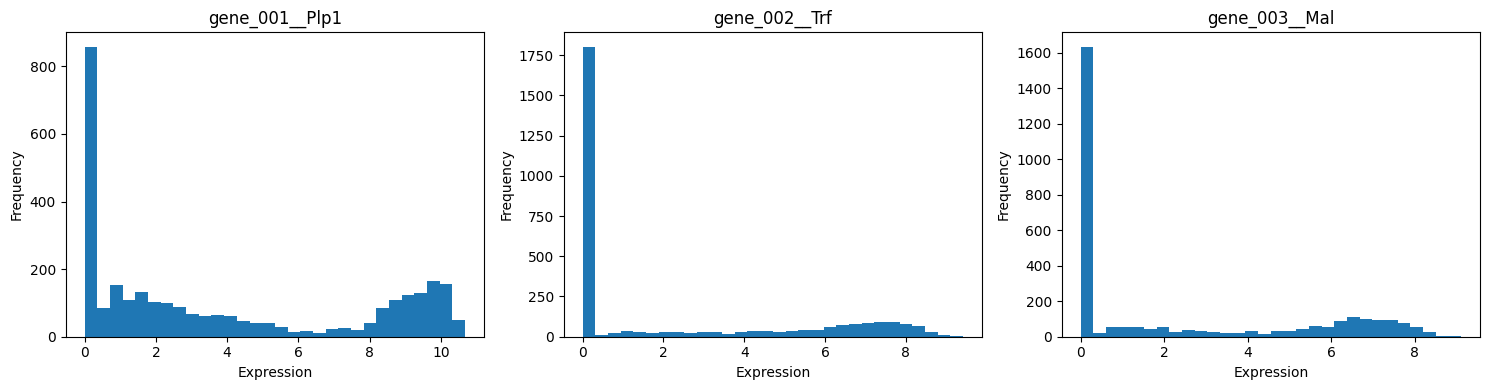

In [5]:
# Section 2 - Visualize distributions for a few genes

selected_gene_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, idx in zip(axes, selected_gene_indices):
    ax.hist(X_raw[:, idx], bins=30)
    ax.set_title(gene_columns[idx])
    ax.set_xlabel("Expression")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


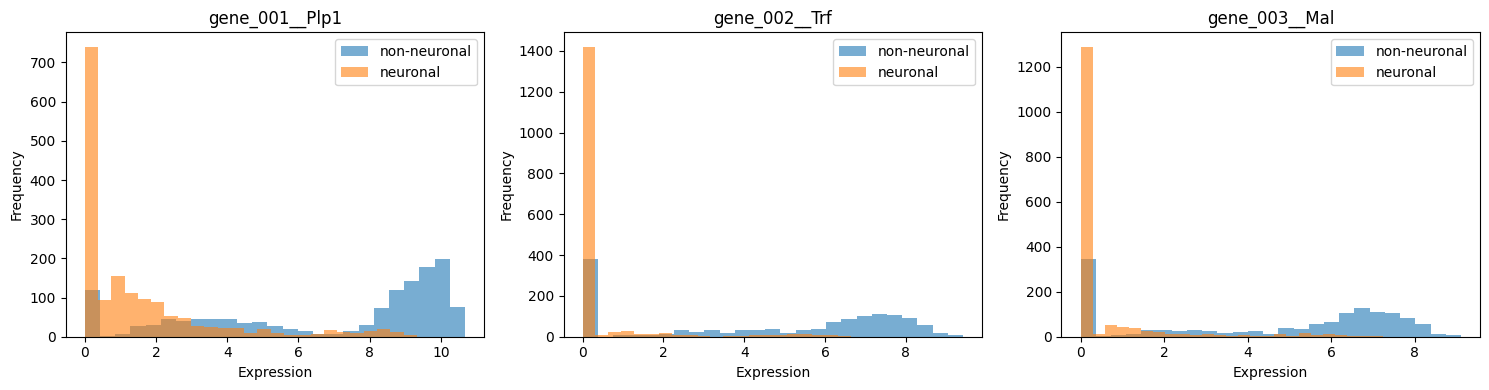

In [6]:
# Section 2 - Compare gene distributions by class

selected_gene_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, idx in zip(axes, selected_gene_indices):
    ax.hist(X_raw[y == 0, idx], bins=25, alpha=0.6, label="non-neuronal")
    ax.hist(X_raw[y == 1, idx], bins=25, alpha=0.6, label="neuronal")
    ax.set_title(gene_columns[idx])
    ax.set_xlabel("Expression")
    ax.set_ylabel("Frequency")
    ax.legend()
    
plt.tight_layout()
plt.show()



If the expression distributions differ between classes, that gene may be informative for classification. Logistic regression combines information from many genes rather than relying on one feature.


In [7]:
# Section 2 - Standardize the gene expression matrix

eps = 1e-8
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / (X_std + eps)

print("Mean of first 5 standardized features:")
print(X[:, :5].mean(axis=0))
print("\nStandard deviation of first 5 standardized features:")
print(X[:, :5].std(axis=0))


Mean of first 5 standardized features:
[ 3.02660466e-16  7.56651166e-17  3.78325583e-17  3.78325583e-17
 -1.51330233e-16]

Standard deviation of first 5 standardized features:
[1. 1. 1. 1. 1.]


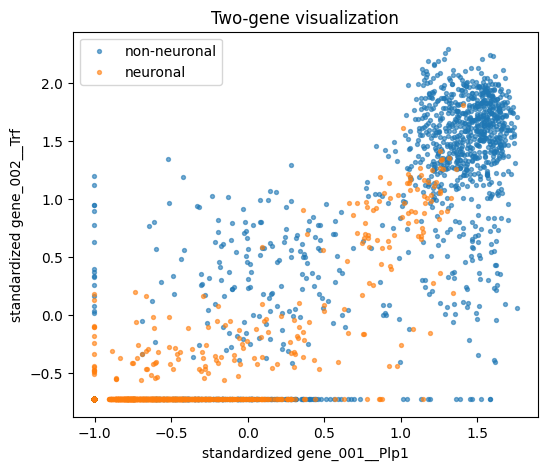

In [8]:
# Section 2 - Two-gene visualization

gene_a = 0
gene_b = 1

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, gene_a], X[y == 0, gene_b], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X[y == 1, gene_a], X[y == 1, gene_b], s=8, alpha=0.6, label="neuronal")
plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Two-gene visualization")
plt.legend()
plt.show()


The two-gene visualization shows a partial separation between neuronal and non-neuronal cells. Non-neuronal cells tend to have higher standardized values of Trf, while neuronal cells are more concentrated at lower Trf values. However, the two classes still overlap, indicating that these two genes alone are not sufficient for perfect classification and that the full model should combine information from multiple genes.

### Exercises for Section 2

**Exercise 2.1** Compute the mean and standard deviation of each gene feature.

**Exercise 2.2** Standardize `X_raw` manually and store it in a new variable.

**Exercise 2.3** Plot the distribution of one gene before and after standardization.

**Exercise 2.4** Look at one gene distribution by class. Does it look informative for classification?


[3.88112772 2.2605409  2.29886397 1.88782965 1.81309992]
[3.86975498 3.12250719 2.99514857 2.7621676  2.66782099]


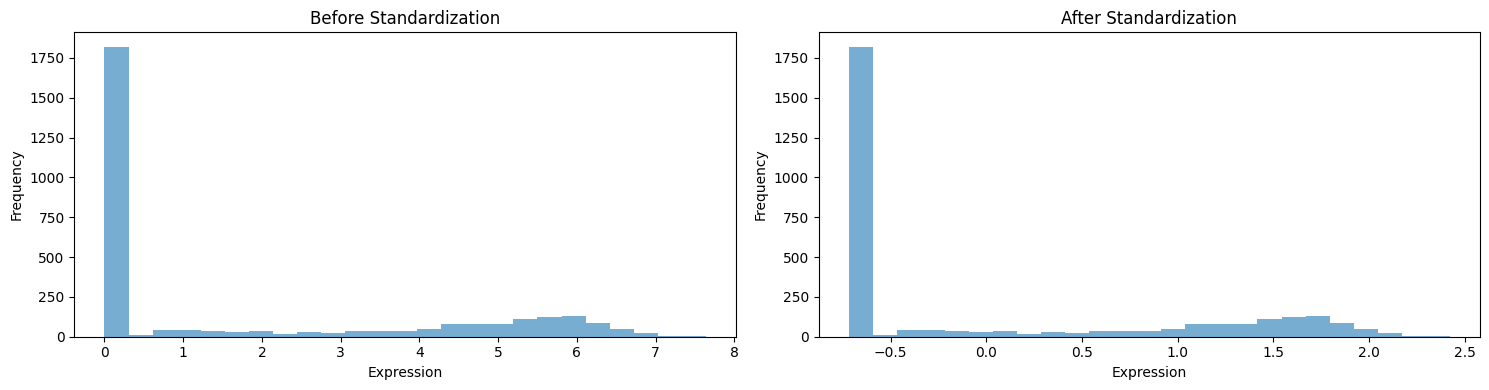

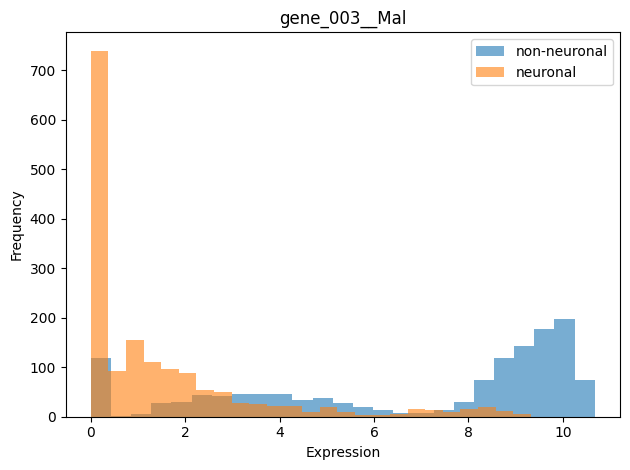

'Taking the first gene of the list, it is clear that this gene is mostly lowly expressed by neuronal cells, with a strong frequency near zero.\nIn non-neuronal cells, on the other hand, the frequency of expression is more distributed and varies among the different subtypes of non-neuronal cells.\nThis could make this gene useful in differentiating between a neuronal and non-neuronal cell.\n'

In [24]:
# Exercises for Section 2

# Ex 2.1
feat_means = np.mean(X_raw, axis=0)
feat_sd = np.std(X_raw, axis=0)
print(feat_means[:5])
print(feat_sd[:5])

# Ex 2.2
X_standr = (X_raw - feat_means) / (feat_sd+1e-8)

# Ex 2.3
gene=10
fig, axes = plt.subplots(1,2, figsize=(15,4))

axes[0].hist(X_raw[:, gene], bins=25, alpha=0.6)
axes[0].set_xlabel("Expression")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Before Standardization")

axes[1].hist(X_standr[:, gene], bins=25, alpha=0.6)
axes[1].set_xlabel("Expression")
axes[1].set_ylabel("Frequency")
axes[1].set_title("After Standardization")
    
plt.tight_layout()
plt.show()

# Ex 2.4
gene = 0

plt.hist(X_raw[y == 0, gene], bins=25, alpha=0.6, label="non-neuronal")
plt.hist(X_raw[y == 1, gene], bins=25, alpha=0.6, label="neuronal")
plt.title(gene_columns[idx])
plt.xlabel("Expression")
plt.ylabel("Frequency")
plt.legend()
    
plt.tight_layout()
plt.show()

"""Taking the first gene of the list, it is clear that this gene is mostly lowly expressed by neuronal cells, with a strong frequency near zero.
In non-neuronal cells, on the other hand, the frequency of expression is more distributed and varies among the different subtypes of non-neuronal cells.
This could make this gene useful in differentiating between a neuronal and non-neuronal cell.
"""

## Section 3 — Train/test split

We split the data into:

- training set: used to learn the parameters
- test set: used to evaluate the classifier on unseen cells

We implement a simple stratified split manually to preserve approximately the same class proportions in training and test data.


In [25]:
# Section 3 - Stratified train/test split

def stratified_train_test_split(X, y, test_fraction=0.25, seed=42):
    rng = np.random.default_rng(seed)
    train_indices = []
    test_indices = []

    for label in np.unique(y):
        label_indices = np.where(y == label)[0] # label_indices=array([12,13,17,21,34...])
        rng.shuffle(label_indices) # label_indices=array([34,12,17,13,21...])
        n_test = int(np.round(test_fraction * len(label_indices)))
        test_indices.extend(label_indices[:n_test]) # append the first 'i' y indices into the test set (751 in case of default)
        train_indices.extend(label_indices[n_test:]) # which leaves the rest for training

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)
    # train and test hold randomized indices, but they are kind  of 'sequenced' by class (train/test=[label0 indices..., label1 indices...])
    # shuffling one more time after the loop is complete ensures true randomness
    rng.shuffle(train_indices) 
    rng.shuffle(test_indices)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices], train_indices, test_indices

X_train, X_test, y_train, y_test, train_idx, test_idx = stratified_train_test_split(
    X, y, test_fraction=0.25, seed=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class counts:", np.unique(y_train, return_counts=True))
print("Test class counts:", np.unique(y_test, return_counts=True))


X_train shape: (2254, 100)
X_test shape: (751, 100)

Training class counts: (array([0, 1]), array([1033, 1221], dtype=int64))
Test class counts: (array([0, 1]), array([344, 407], dtype=int64))


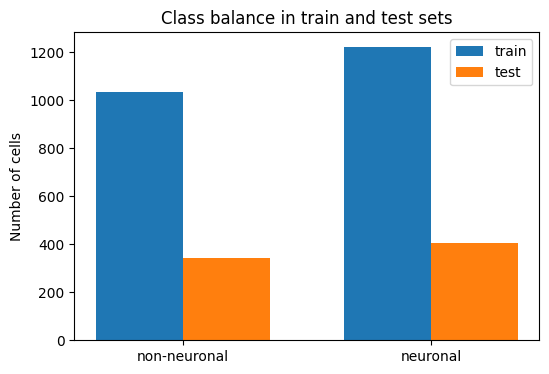

In [26]:
# Section 3 - Visualize class balance in train and test sets

train_counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
test_counts = [np.sum(y_test == 0), np.sum(y_test == 1)]

x_pos = np.arange(2)
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x_pos - width / 2, train_counts, width, label="train")
plt.bar(x_pos + width / 2, test_counts, width, label="test")
plt.xticks(x_pos, ["non-neuronal", "neuronal"])
plt.ylabel("Number of cells")
plt.title("Class balance in train and test sets")
plt.legend()
plt.show()


### Exercises for Section 3

**Exercise 3.1** Compute the percentage of neuronal cells in the full dataset, training set, and test set.

**Exercise 3.2** Why is it useful to preserve class proportions in train and test sets?

**Exercise 3.3** What could go wrong if the test set contains almost only one class?


In [35]:
# Exercises for Section 3

# Ex 3.1
print((len(y[y==1])/len(y))*100) 
print((len(y_train[y_train==1])/len(y_train))*100)
print((len(y_test[y_test==1])/len(y_test))*100)
""" almost 55% of the total cells are neuronal in all these forms of y"""

# Ex 3.2
"""It is important to do so in order to preserve the true shape of the data in nature when training and testing the model.
For instance, If the classes are balanced in nature, but the training/test sets are highly imbalanced, then the final model will not capture the true
distribution of the data, rendering it weak in predictions."""

# Ex 3.3
"""As mentioned in the previous part, a highly imbalanced dataset will create bias towards the majority class, yielding parameter estimates that do not
reflect the true nature of the data."""

54.176372712146424
54.170363797692985
54.19440745672437


'As mentioned in the previous part, a highly imbalanced dataset will create bias towards the majority class, yielding parameter estimates that do not\nreflect the true nature of the data.'

## Section 4 — Linear scores and threshold classifiers

A linear classifier first computes a score:

$$
s = Xw + b
$$

Then it assigns a class using a threshold:

$$
\hat{y} =
\begin{cases}
1 & \text{if } s \geq 0 \\
0 & \text{if } s < 0
\end{cases}
$$

The score is not a probability. It can be any real number. This motivates logistic regression.


In [41]:
# Section 4 - Linear scores with arbitrary parameters
# These weights are not learned from data.
# We set the first two weights to 1 and -1 only to create a simple example:
# score = gene_001 - gene_002.
# All other genes have weight 0 and do not contribute to the score.

w_example = np.zeros(X_train.shape[1]) # array([0,0,0,0...]) of length 100 (as many gene features in the dataset.
                                                                    # ==> Each feat gets a weight of contribution for predicting the label)
w_example[0] = 1.0
w_example[1] = -1.0
b_example = 0.0

scores_example = X_train @ w_example + b_example
y_pred_example = (scores_example >= 0).astype(int) # returns 1 if True and False otherwise

print("First 10 scores:")
print(scores_example[:10]) # scores can go from -inf to +inf (it is a linear regression model)
print("\nFirst 10 predicted labels:")
print(y_pred_example[:10])
print("\nFirst 10 true labels:")
print(y_train[:10])


First 10 scores:
[-0.2789883   0.76660836 -0.2789883   0.29027433 -0.01671054 -0.04491821
 -0.22553548 -0.2789883   0.09096722 -0.2789883 ]

First 10 predicted labels:
[0 1 0 1 0 0 0 0 1 0]

First 10 true labels:
[1 0 1 0 1 0 0 1 0 1]


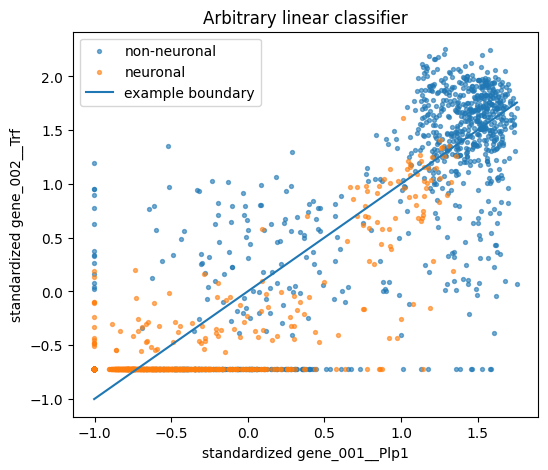

In [39]:
# Section 4 - Visualize arbitrary linear decision boundary using two genes

plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train == 0, gene_a], X_train[y_train == 0, gene_b], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_train[y_train == 1, gene_a], X_train[y_train == 1, gene_b], s=8, alpha=0.6, label="neuronal")

x_values = np.linspace(X_train[:, gene_a].min(), X_train[:, gene_a].max(), 100)
if abs(w_example[gene_b]) > 1e-12:
    y_boundary = -(w_example[gene_a] * x_values + b_example) / w_example[gene_b]
    plt.plot(x_values, y_boundary, label="example boundary")

plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Arbitrary linear classifier")
plt.legend()
plt.show()


The line separates the two-dimensional feature space into two regions. However, the boundary is produced from arbitrary parameters, not learned parameters.

### Exercises for Section 4

**Exercise 4.1** Compute linear scores using another pair of arbitrary weights.

**Exercise 4.2** Convert scores into predicted labels using a threshold at zero.

**Exercise 4.3** Why is the raw score not a probability?

**Exercise 4.4** In two dimensions, what geometric object is the decision boundary?


In [43]:
# Exercises for Section 4

# Ex 4.1
w_example[0] = 2.0
w_example[1] = 3.0
b_example = 0.0

scores_example = X_train @ w_example + b_example

print("First 10 scores:")
print(scores_example[:10]) # scores can go from -inf to +inf (it is a linear regression model)

# Ex 4.2
y_pred_example = (scores_example >= 0).astype(int)
print(y_pred_example[:10])

# Ex 4.3
"""Because it is a linear model that calculates the raw score of the output from the values of each feat and the corresponding weights"""

# Ex 4.4
"""It is a vertical line that separates between the two classes (threshold being 0)"""

First 10 scores:
[-4.17772949 -2.08653616 -4.17772949  7.25503288 -3.65317396  8.04036331
  8.92481749 -4.17772949  8.16948633 -4.17772949]
[0 0 0 1 0 1 1 0 1 0]


## Section 5 — Sigmoid function and probabilistic interpretation

Logistic regression converts a linear score into a probability using the sigmoid function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The logistic regression hypothesis is:

$$
\hat{y} = \sigma(Xw + b)
$$

The output is between 0 and 1, so it can be interpreted as:

$$
\hat{y}_i = P(y_i = 1 \mid x_i)
$$

In this lab, this means the predicted probability that a cell is neuronal.


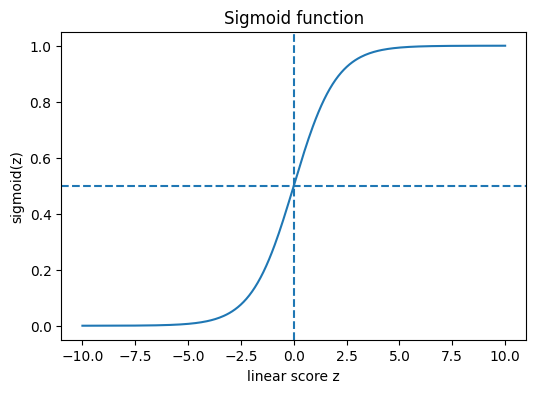

In [49]:
# Section 5 - Sigmoid function

def sigmoid(z):
    z = np.clip(z, -500, 500) # z is the vector of scores for each cell (it ensures that all values are between -500 and 500)
    return 1 / (1 + np.exp(-z)) # each score is converted to a probabilistic value lying between 0 and 1
    
z_grid = np.linspace(-10, 10, 300)

# This allows us to see the shape of the generated curve (sigmoid)
plt.figure(figsize=(6, 4))
plt.plot(z_grid, sigmoid(z_grid))
plt.axhline(0.5, linestyle="--")
plt.axvline(0.0, linestyle="--")
plt.xlabel("linear score z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid function")
plt.show()


In [50]:
# Section 5 - Convert arbitrary scores into probabilities

prob_example = sigmoid(scores_example)

print("First 10 scores:")
print(scores_example[:10])
print("\nFirst 10 probabilities:")
print(prob_example[:10])


First 10 scores:
[-4.17772949 -2.08653616 -4.17772949  7.25503288 -3.65317396  8.04036331
  8.92481749 -4.17772949  8.16948633 -4.17772949]

First 10 probabilities:
[0.01510172 0.11041234 0.01510172 0.99929389 0.02525445 0.99967791
 0.99986697 0.01510172 0.99971692 0.01510172]


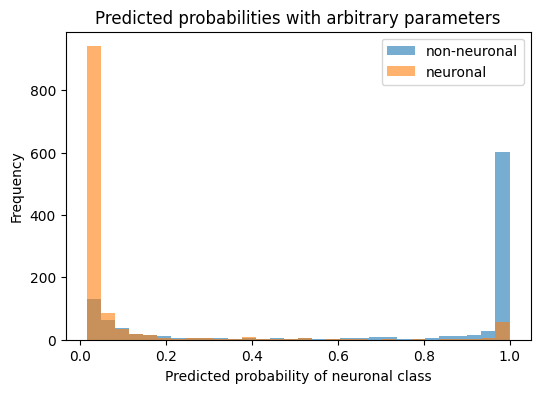

In [51]:
# Section 5 - Visualize predicted probabilities from arbitrary parameters

plt.figure(figsize=(6, 4))
plt.hist(prob_example[y_train == 0], bins=30, alpha=0.6, label="non-neuronal")
plt.hist(prob_example[y_train == 1], bins=30, alpha=0.6, label="neuronal")
plt.xlabel("Predicted probability of neuronal class")
plt.ylabel("Frequency")
plt.title("Predicted probabilities with arbitrary parameters")
plt.legend()
plt.show()


The histogram shows the predicted probability of the neuronal class using arbitrary parameters. Many neuronal cells receive high probabilities, but some non-neuronal cells also fall in the same high-probability region, suggesting potential false positives. Since these parameters have not been learned from the data, this plot should be interpreted only as an illustration of how linear scores are transformed into probabilities by the sigmoid function.

### Exercises for Section 5

**Exercise 5.1** Compute sigmoid values for `z = -5, 0, 5`.

**Exercise 5.2** What is the value of the sigmoid function when `z = 0`?

**Exercise 5.3** Why is the sigmoid useful for binary classification?

**Exercise 5.4** What class would you predict if the predicted probability is `0.8`?


In [56]:
# Exercises for Section 5

# Ex 5.1
z = [-5,0,5]
display(sigmoid(z))

# Ex 5.2
"""0.5, which means that a score of zero from the linear model makes it equally likely to be part of either the first class or the second class"""

# Ex 5.3
"""The sigmoid function is useful because it smoothly narrows down any score from the model to lie between 0 and 1
This facilitates interpretation since each value represents a probability, where a small probabilty reflects its unlikeliness to be in the success class
It also makes it easy to define a threshold, since a raw score of 0 maps to 0.5.
This makes it easy to create a decision boundary and interpret prediction confidence depending on the size of the probability value.
It is also useful for gradient-descent optimization since the model function is smooth and differentiable.
"""

# Ex 5.4
"""I would predict it to be in class 1"""

array([0.00669285, 0.5       , 0.99330715])

'I would predict it to be in class 1'

## Section 6 — Binary Cross-Entropy loss

For logistic regression, we use Binary Cross-Entropy (BCE), also called log-loss:

$$
J(w,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{y}_i) +
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

This loss is designed to be small when the model assigns high probability to the correct class, and very large when the model is confidently wrong.


In [57]:
# Section 6 - Binary Cross-Entropy loss

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps) # y_prob is ensured to be between eps and 1-eps
    return -np.mean(
        y_true * np.log(y_prob) +
        (1 - y_true) * np.log(1 - y_prob)
    )

bce_example = binary_cross_entropy(y_train, prob_example)
print("Binary Cross-Entropy with arbitrary parameters:")
print(bce_example)


Binary Cross-Entropy with arbitrary parameters:
3.92527763175018


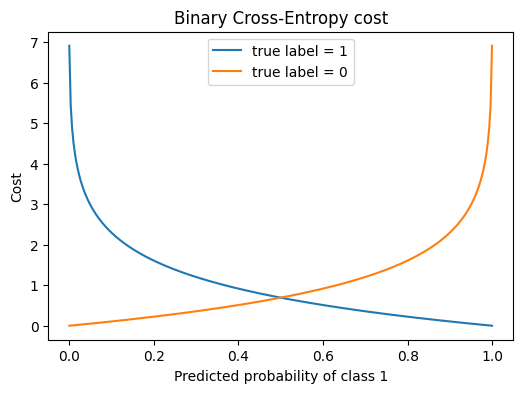

In [58]:
# Section 6 - Visualize BCE cost for y=1 and y=0

p_grid = np.linspace(0.001, 0.999, 300)
cost_if_y1 = -np.log(p_grid)
cost_if_y0 = -np.log(1 - p_grid)

plt.figure(figsize=(6, 4))
plt.plot(p_grid, cost_if_y1, label="true label = 1")
plt.plot(p_grid, cost_if_y0, label="true label = 0")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Cost")
plt.title("Binary Cross-Entropy cost")
plt.legend()
plt.show()


The Binary Cross-Entropy (BCE) cost is low when the model assigns high probability to the correct class, and it becomes very large when the model is confidently wrong. For a true label equal to 1, the cost increases as the predicted probability of class 1 approaches 0. For a true label equal to 0, the cost increases as the predicted probability of class 1 approaches 1.

### Exercises for Section 6

**Exercise 6.1** Compute BCE for the arbitrary probabilities `prob_example`.

**Exercise 6.2** What happens to the cost when the true label is `1` but the predicted probability is close to `0`?

**Exercise 6.3** What happens to the cost when the true label is `0` but the predicted probability is close to `1`?

**Exercise 6.4** Why is BCE more appropriate than MSE for logistic regression?


In [ ]:
# Exercises for Section 6

# Ex 6.1
print(binary_cross_entropy(y_train, prob_example))

# Ex 6.2
"""The cost increases since we are farther away from the true value"""

# Ex 6.3
"""The same as stated in the previous part. In fact, looking at the plot, the relationship is almost identical on both sides."""

# Ex 6.4
"""That is because we are dealing with probability values that lie between zero and 1.
MSE would not capture the true intensity of being misclassified since all values are relatively close to each other (only 0 and 1).
for instance, a cell having a 0.1 prob of being in class 1 when it is in truth a neuronal cell would be appreciated enough by MSE as it would by BCE.
"""

## Section 7 — Gradient Descent for logistic regression

For BCE loss, the gradients are:

$$
\frac{\partial J}{\partial w} = \frac{1}{n} X^T(\hat{y} - y)
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)
$$

This looks similar to the linear regression gradient, but now predictions are probabilities produced by the sigmoid function.


In [59]:
# Section 7 - Logistic regression from scratch

def predict_probs(X, w, b):
    return sigmoid(X @ w + b)

def compute_logistic_gradients(X, y, w, b):
    n = X.shape[0]
    y_prob = predict_probs(X, w, b)
    error = y_prob - y
    dw = (X.T @ error) / n
    db = np.mean(error)
    return dw, db

def train_logistic_regression(X, y, learning_rate=0.1, n_steps=500):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for step in range(n_steps):
        y_prob = predict_probs(X, w, b)
        loss = binary_cross_entropy(y, y_prob)
        loss_history.append(loss)

        dw, db = compute_logistic_gradients(X, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, loss_history

w_fit, b_fit, loss_history = train_logistic_regression(
    X_train, y_train, learning_rate=0.1, n_steps=800
)

print("Training loss with arbitrary parameters:", bce_example)
print("Initial training loss:", loss_history[0])
print("Final training loss:", loss_history[-1])
print("First 5 fitted coefficients:", w_fit[:5])
print("Fitted bias:", b_fit)


Training loss with arbitrary parameters: 3.92527763175018
Initial training loss: 0.6931471805599454
Final training loss: 0.030216676411638967
First 5 fitted coefficients: [-0.09288997 -0.11685138 -0.06337634 -0.05638829 -0.0753874 ]
Fitted bias: -0.3184926697542847


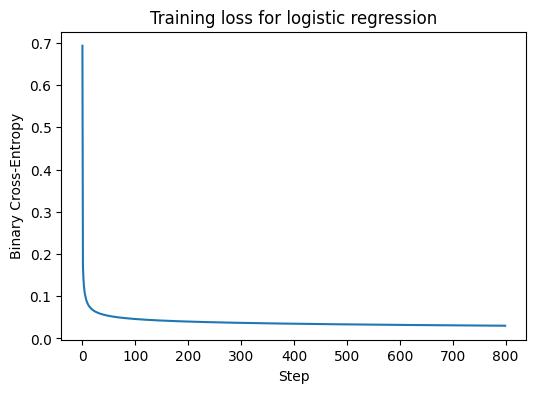

In [60]:
# Section 7 - Plot training loss

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training loss for logistic regression")
plt.show()



As in Lab 1, the training curve shows the value of the loss function during Gradient Descent (GD).

The difference is that in Lab 1 we minimized the Mean Squared Error (MSE) for a regression problem, while here we minimize the Binary Cross-Entropy (BCE) for a binary classification problem.

In both cases, the goal of Gradient Descent is the same: update the model parameters step by step to reduce the loss.

### Exercises for Section 7

**Exercise 7.1** Train logistic regression with a different learning rate.

**Exercise 7.2** Plot the training loss.

**Exercise 7.3** Does the loss decrease over time?

**Exercise 7.4** Check the shape of `w_fit`. Why does it have this shape?


Initial loss: 0.6931471805599454
Final loss: 0.048461416667034775


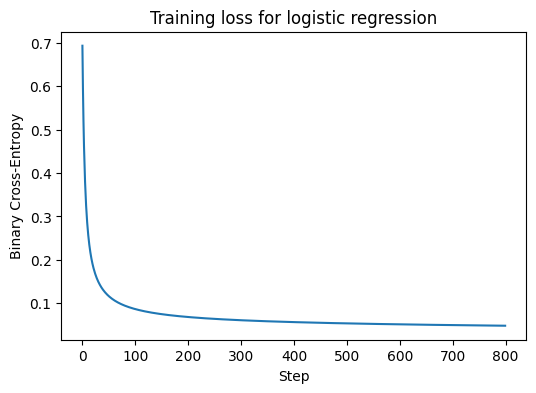

(100,)


In [63]:
# Exercises for Section 7

# Ex 7.1
w_fit, b_fit, loss_history = train_logistic_regression(
    X_train, y_train, learning_rate=0.01, n_steps=800
)
print("Initial loss:",loss_history[0])
print("Final loss:", loss_history[-1])
# we notice that the final loss (.04) is larger than the one obtained from lr=0.1 (.03) since 0.1>0.01 => learning is faster, hence descent is sharper.

# Ex 7.2
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training loss for logistic regression")
plt.show()

# Ex 7.3
"""Yes, and that makes sense since the weights of the features are being adjusted more every loop, following the gradient descent."""

# Ex 7.4
print(w_fit.shape)
"""It is a 1D vector that holds the weights (coefficients) of each gene feature, and it is a single value, hence 1D"""

## Section 8 — Model evaluation for binary classification

We convert predicted probabilities into class labels using threshold 0.5:

$$
\hat{y}_{class} =
\begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{if } \hat{y} < 0.5
\end{cases}
$$

We compute accuracy, confusion matrix, precision, and recall.

The **accuracy** is the fraction of cells that are correctly classified. It gives a general summary of performance, but it can be misleading when the two classes are imbalanced.

The **confusion matrix** shows the number of correct and incorrect predictions for each class. It separates true positives, true negatives, false positives, and false negatives, making it easier to understand which type of error the classifier is making.

The **precision** answers the question: among the cells predicted as neuronal, how many are truly neuronal? High precision means that the classifier produces few false positives.

The **recall** answers the question: among all truly neuronal cells, how many are correctly detected by the classifier? High recall means that the classifier produces few false negatives.


In [64]:
# Section 8 - Classification metrics

# The `predict_class` function converts predicted probabilities into binary class predictions 
# based on a specified threshold (default is 0.5). If the predicted probability of class 1 is 
# greater than or equal to the threshold, it predicts class 1; otherwise, it predicts class 0.
def predict_class(X, w, b, threshold=0.5):
    return (predict_probs(X, w, b) >= threshold).astype(int)

# The `accuracy_score` function computes the accuracy of predictions by comparing the true labels (`y_true`) 
# with the predicted labels (`y_pred`). It returns the mean of correct predictions, which is the proportion of 
# samples that were correctly classified.
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

# The `confusion_matrix_binary` function computes the confusion matrix for binary classification. 
# It counts the number of true negatives (tn), false positives (fp), false negatives (fn), and true positives (tp)
# by comparing the true labels (`y_true`) with the predicted labels (`y_pred`). The function returns a 2x2 NumPy 
# array representing the confusion matrix.
def confusion_matrix_binary(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

# The `precision_score` function calculates the precision of the binary classification by using the confusion matrix.
# Precision is defined as the ratio of true positives (tp) to the sum of true positives and false positives (fp).
# A small constant (1e-12) is added to the denominator to avoid division by zero when there are no positive predictions.
def precision_score(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp + 1e-12)

# The `recall_score` function calculates the recall of the binary classification by using the confusion matrix.
# Recall is defined as the ratio of true positives (tp) to the sum of true positives and false negatives (fn).
# A small constant (1e-12) is added to the denominator to avoid division by zero when there are no true positives.
def recall_score(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn + 1e-12)


In [65]:
# Section 8 - Evaluate train and test performance

y_train_pred = predict_class(X_train, w_fit, b_fit)
y_test_pred = predict_class(X_test, w_fit, b_fit)

print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test precision:", precision_score(y_test, y_test_pred))
print("Test recall:", recall_score(y_test, y_test_pred))

cm_test = confusion_matrix_binary(y_test, y_test_pred)


Training accuracy: 0.9809228039041704
Test accuracy: 0.9800266311584553
Test precision: 0.9688995215310982
Test recall: 0.9950859950859926


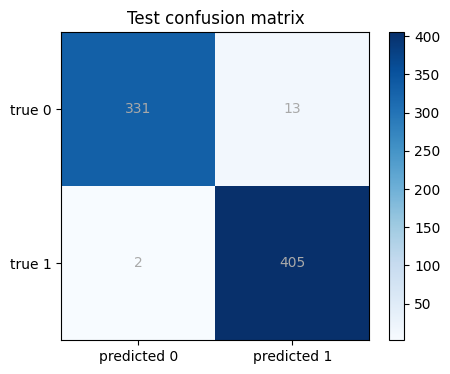

In [66]:
# Section 8 - Plot confusion matrix

plt.figure(figsize=(5, 4))
plt.imshow(cm_test, cmap="Blues")
plt.xticks([0, 1], ["predicted 0", "predicted 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
plt.title("Test confusion matrix")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_test[i, j], ha="center", va="center", color="darkgrey")

plt.show()


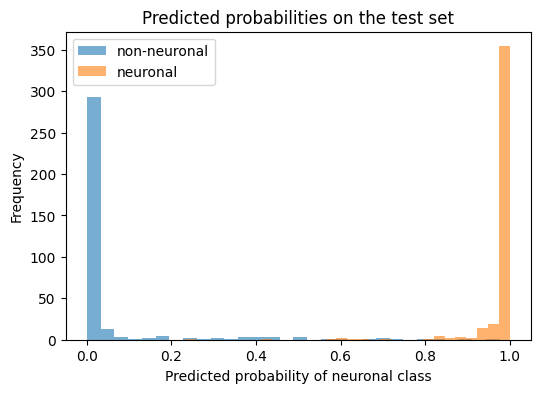

In [67]:
# Section 8 - Predicted probability distributions on the test set

test_prob = predict_probs(X_test, w_fit, b_fit)

plt.figure(figsize=(6, 4))
plt.hist(test_prob[y_test == 0], bins=30, alpha=0.6, label="non-neuronal")
plt.hist(test_prob[y_test == 1], bins=30, alpha=0.6, label="neuronal")
plt.xlabel("Predicted probability of neuronal class")
plt.ylabel("Frequency")
plt.title("Predicted probabilities on the test set")
plt.legend()
plt.show()


This plot shows the distribution of predicted probabilities for the two true classes in the test set. It complements the confusion matrix because it shows how confident the classifier is, not only whether the final class prediction is correct. Here, most non-neuronal cells receive probabilities close to 0, while most neuronal cells receive probabilities close to 1, indicating a strong separation between the two classes. Cells near 0.5 would represent uncertain cases close to the decision threshold.

### Exercises for Section 8

**Exercise 8.1** Compute accuracy on the training set and on the test set.

**Exercise 8.2** Compute the confusion matrix on the test set.

**Exercise 8.3** Explain what false positives and false negatives mean in this biological task.

**Exercise 8.4** Is accuracy alone sufficient to understand classifier performance?


In [69]:
# Exercises for Section 8

# Ex 8.1
y_train_pred = predict_class(X_train, w_fit, b_fit)
y_test_pred = predict_class(X_test, w_fit, b_fit)

print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

# Ex 8.2
cm = confusion_matrix_binary(y_test, y_test_pred)
print(cm)

# Ex 8.3
"""False positives are the cells that have been classified as neuronal when in truth they are not.
False negatives are the cells that have been classified as non-neuronal when in truth they are neuronal."""

# Ex 8.4
"""The general consensus says it is better to look at precision and recall as well (maybe even calculate F1-score metric).
That is because, especially if the data is imbalanced, accuracy might be very high when it truth it is only high because the majority of observations
are of the same class, so the false classifications do not impact the score as much. This can cause misguided results about the success of the model"""


Training accuracy: 0.9809228039041704
Test accuracy: 0.9800266311584553
[[331  13]
 [  2 405]]


## Section 9 — Decision boundary in two dimensions

The full model uses many genes, so its decision boundary is a hyperplane in high-dimensional space. To visualize the idea, we train a logistic regression model using only two genes.


In [71]:
# Section 9 - Train logistic regression on two selected genes

X_train_2d = X_train[:, [gene_a, gene_b]]
X_test_2d = X_test[:, [gene_a, gene_b]]

w_2d, b_2d, loss_2d = train_logistic_regression(
    X_train_2d, y_train, learning_rate=0.1, n_steps=800
)

print("2D model weights:", w_2d)
print("2D model bias:", b_2d)

print(loss_2d[-1])

2D model weights: [-1.24667364 -0.88691381]
2D model bias: -0.05671402871600558
0.40802909294632334


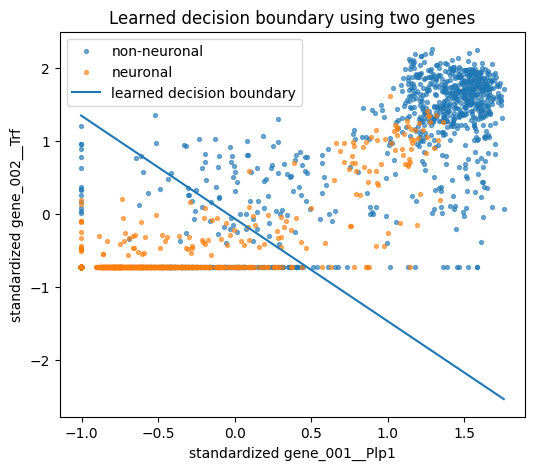

In [72]:
# Section 9 - Plot learned decision boundary

plt.figure(figsize=(6, 5))
plt.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], s=8, alpha=0.6, label="neuronal")

x_values = np.linspace(X_train_2d[:, 0].min(), X_train_2d[:, 0].max(), 100)
if abs(w_2d[1]) > 1e-12:
    y_boundary = -(w_2d[0] * x_values + b_2d) / w_2d[1]
    plt.plot(x_values, y_boundary, label="learned decision boundary")

plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Learned decision boundary using two genes")
plt.legend()
plt.show()


### Exercises for Section 9

**Exercise 9.1** Train a two-gene classifier using a different pair of genes.

**Exercise 9.2** Plot the corresponding decision boundary.

**Exercise 9.3** Why can the full model perform better than the two-gene model?


In [75]:
# Exercises for Section 9

# Ex 9.1
X_tr_2d = X_train[:, [10, 15]]
X_te_2d = X_test[:, [10, 15]]

w_2d, b_2d, loss_2d = train_logistic_regression(
    X_train_2d, y_train, learning_rate=0.1, n_steps=800
)

print("2D model weights:", w_2d)
print("2D model bias:", b_2d)

# Ex 9.2
plt.figure(figsize=(6, 5))
plt.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], s=8, alpha=0.6, label="neuronal")

x_values = np.linspace(X_train_2d[:, 0].min(), X_train_2d[:, 0].max(), 100)
if abs(w_2d[1]) > 1e-12:
    y_boundary = -(w_2d[0] * x_values + b_2d) / w_2d[1]
    plt.plot(x_values, y_boundary, label="learned decision boundary")

plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Learned decision boundary using two genes")
plt.legend()
plt.show()

# Ex 9.3
"""That is because, with more features, the model is able to better understand the nature of the observations, correctly evaluating the weight that
each feature deserves. With only two genes as features, the model is limited to understanding the cells from the perspective of these two genes alone,
leaving a lot of variance in the data that cannot be explained by these two features alone. Therefore, misclassifications are more bound to happen."""

2D model weights: [-1.24667364 -0.88691381]
2D model bias: -0.05671402871600558
0.40802909294632334


## Section 10 — L2 regularization

When a model has many features, it can overfit the training data. Regularization reduces overfitting by penalizing large coefficients.

L2 regularization adds a penalty proportional to the sum of squared weights. This discourages very large coefficients, making the model simpler and less prone to overfitting, while still allowing all features to contribute to the prediction.

For logistic regression with L2 regularization, the objective becomes:


$$
J(w,b) = \mathrm{BCE}(w,b) + \underbrace{\frac{\lambda}{2n}\sum_{j=1}^{p} w_j^2}_{\text{L2 regularization}}
$$

We regularize the weights `w`, but not the bias `b`.

Here we define the functions needed for implementing the logistic regression with L2 regularization.


In [76]:
# Section 10 - Regularized logistic regression functions

def binary_cross_entropy_l2(y_true, y_prob, w, lambda_reg=0.0):
    bce = binary_cross_entropy(y_true, y_prob)
    l2_penalty = (lambda_reg / (2 * len(y_true))) * np.sum(w ** 2)
    return bce + l2_penalty

def compute_logistic_gradients_l2(X, y, w, b, lambda_reg=0.0):
    n = X.shape[0]
    y_prob = predict_probs(X, w, b)
    error = y_prob - y
    dw = (X.T @ error) / n
    db = np.mean(error)
    dw = dw + (lambda_reg / n) * w
    return dw, db

def train_logistic_regression_l2(X, y, learning_rate=0.1, n_steps=500, lambda_reg=0.0):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for step in range(n_steps):
        y_prob = predict_probs(X, w, b)
        loss = binary_cross_entropy_l2(y, y_prob, w, lambda_reg=lambda_reg)
        loss_history.append(loss)
        dw, db = compute_logistic_gradients_l2(X, y, w, b, lambda_reg=lambda_reg)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, loss_history


Here we train the same logistic regression model several times, changing only the L2 regularization strength `lambda_reg`. For each model, we record training accuracy, test accuracy, and the L2 norm of the coefficient vector. This lets us check whether stronger regularization reduces coefficient magnitude and whether this affects predictive performance.

In [77]:
# Section 10 - Train models with different regularization strengths

lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]
regularization_results = []

for lambda_reg in lambda_values:
    w_reg, b_reg, hist_reg = train_logistic_regression_l2(
        X_train, y_train, learning_rate=0.1, n_steps=800, lambda_reg=lambda_reg
    )

    y_train_pred_reg = predict_class(X_train, w_reg, b_reg)
    y_test_pred_reg = predict_class(X_test, w_reg, b_reg)

    regularization_results.append({
        "lambda": lambda_reg,
        "w": w_reg,
        "b": b_reg,
        "loss_history": hist_reg,
        "train_accuracy": accuracy_score(y_train, y_train_pred_reg),
        "test_accuracy": accuracy_score(y_test, y_test_pred_reg),
        "coef_norm": np.sqrt(np.sum(w_reg ** 2))
    })

results_df = pd.DataFrame([
    {"lambda": r["lambda"], "train_accuracy": r["train_accuracy"],
     "test_accuracy": r["test_accuracy"], "coef_norm": r["coef_norm"]}
    for r in regularization_results
])

display(results_df)


,lambda,train_accuracy,test_accuracy,coef_norm
0,0.00,0.987578,0.984021,1.777559
1,0.01,0.987578,0.984021,1.777307
2,0.10,0.987578,0.984021,1.775046
3,1.00,0.987578,0.984021,1.752837
4,10.00,0.988465,0.984021,1.566018


In this dataset, increasing L2 regularization reduces the magnitude of the coefficients while keeping classification performance almost unchanged. This suggests that the model can remain accurate with smaller, more regularized weights.

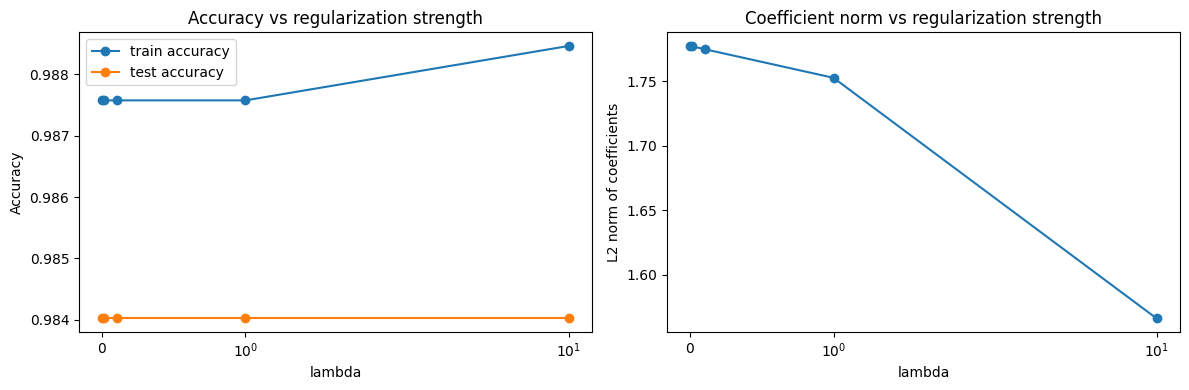

In [78]:
# Section 10 - Visualize effect of regularization side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    results_df["lambda"],
    results_df["train_accuracy"],
    marker="o",
    label="train accuracy"
)
axes[0].plot(
    results_df["lambda"],
    results_df["test_accuracy"],
    marker="o",
    label="test accuracy"
)
axes[0].set_xscale("symlog")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs regularization strength")
axes[0].legend()

axes[1].plot(
    results_df["lambda"],
    results_df["coef_norm"],
    marker="o"
)
axes[1].set_xscale("symlog")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("L2 norm of coefficients")
axes[1].set_title("Coefficient norm vs regularization strength")

plt.tight_layout()
plt.show()


The first plot shows that training and test accuracy remain almost unchanged across the tested values of `lambda`. This means that, in this dataset, stronger L2 regularization does not substantially affect classification performance.

The second plot shows the expected effect of L2 regularization: as `lambda` increases, the L2 norm of the coefficient vector decreases. In other words, the model keeps a similar predictive performance while using smaller coefficients, which corresponds to a simpler and more regularized solution.

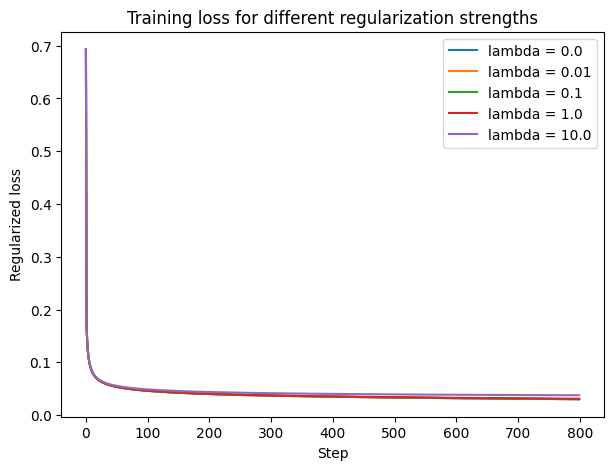

In [79]:
# Section 10 - Compare loss curves for different regularization strengths

plt.figure(figsize=(7, 5))

for result in regularization_results:
    plt.plot(result["loss_history"], label=f"lambda = {result['lambda']}")

plt.xlabel("Step")
plt.ylabel("Regularized loss")
plt.title("Training loss for different regularization strengths")
plt.legend()
plt.show()


The loss curves decrease rapidly during the first iterations and then approach a plateau, indicating that Gradient Descent (GD) is effectively optimizing the model. The curves for different values of `lambda` are almost overlapping, suggesting that the tested levels of L2 regularization do not substantially change the optimization dynamics in this dataset. However, the loss shown here is the regularized objective, so larger values of `lambda` include a stronger penalty on large coefficients.


### Exercises for Section 10

**Exercise 10.1** Train logistic regression with `lambda_reg = 0.0`, `0.1`, and `10.0`.

**Exercise 10.2** Compare training accuracy and test accuracy.

**Exercise 10.3** Compare the L2 norm of the coefficient vector.

**Exercise 10.4** What happens when regularization becomes very strong?

**Exercise 10.5** Why do we regularize the weights but not the bias?


In [82]:
# Exercises for Section 10

# Ex 10.1
lambda_values = [0.0, 0.1, 10.0]
regularization_results = []

for lambda_reg in lambda_values:
    w_reg, b_reg, hist_reg = train_logistic_regression_l2(
        X_train, y_train, learning_rate=0.1, n_steps=800, lambda_reg=lambda_reg
    )

    y_train_pred_reg = predict_class(X_train, w_reg, b_reg)
    y_test_pred_reg = predict_class(X_test, w_reg, b_reg)

    regularization_results.append({
        "lambda": lambda_reg,
        "w": w_reg,
        "b": b_reg,
        "loss_history": hist_reg,
        "train_accuracy": accuracy_score(y_train, y_train_pred_reg),
        "test_accuracy": accuracy_score(y_test, y_test_pred_reg),
        "coef_norm": np.sqrt(np.sum(w_reg ** 2))
    })

# Ex 10.2
results_df = pd.DataFrame([
    {"lambda": r["lambda"], "train_accuracy": r["train_accuracy"],
     "test_accuracy": r["test_accuracy"]}
    for r in regularization_results
])

display(results_df)

# Ex 10.3
results_df = pd.DataFrame([
    {"lambda": r["lambda"], "coef-norm":r["coef_norm"]}
    for r in regularization_results
])

display(results_df)

# Ex 10.4
"""It is a double-edged sword. Increasing regularization decreases the chances of overfitting since the coefficients are shrinking towards zero.
However, it also means that the model might not capture all the variance in the data anymore, because of this shrinkage, leading to an underfit model.
"""

# Ex 10.5
"""We do that since the bias only shifts the prediction function up or down. It does not contribute to the complexity of the model like the weights do.
"""

,lambda,train_accuracy,test_accuracy
0,0.0,0.987578,0.984021
1,0.1,0.987578,0.984021
2,10.0,0.988465,0.984021


,lambda,coef-norm
0,0.0,1.777559
1,0.1,1.775046
2,10.0,1.566018


## Section 11 — Biological interpretation of coefficients

A positive coefficient means that higher expression of that gene pushes the model toward the neuronal class.

A negative coefficient means that higher expression of that gene pushes the model toward the non-neuronal class.

Important caution: coefficients indicate associations used by the classifier. They do not prove causal biological roles.


In [83]:
# Section 11 - Select a regularized model for interpretation

selected_lambda = 0.1
selected_result = [r for r in regularization_results if r["lambda"] == selected_lambda][0]

w_selected = selected_result["w"]
b_selected = selected_result["b"]

print("Selected lambda:", selected_lambda)
print("Selected model test accuracy:", selected_result["test_accuracy"])


Selected lambda: 0.1
Selected model test accuracy: 0.9840213049267643


In [84]:
# Section 11 - Inspect top positive and negative coefficients

n_top = 10
sorted_indices = np.argsort(w_selected)

top_negative_idx = sorted_indices[:n_top]
top_positive_idx = sorted_indices[-n_top:][::-1]

print("Top positive coefficients:")
for idx in top_positive_idx:
    print(gene_columns[idx], w_selected[idx])

print("\nTop negative coefficients:")
for idx in top_negative_idx:
    print(gene_columns[idx], w_selected[idx])


Top positive coefficients:
gene_096__Rasgrp1 0.3569316728365828
gene_022__Stmn3 0.3510404320012727
gene_052__Stmn2 0.34127184387304765
gene_088__Grm5 0.3344972758565315
gene_064__Ndrg4 0.3300679593520051
gene_059__Nsf 0.31152875185111334
gene_062__Atp1a3 0.2973962368041896
gene_068__Cck 0.2960011489330445
gene_056__Gria1 0.29394747946243727
gene_079__Ntm 0.2906850131807659

Top negative coefficients:
gene_049__Sparc -0.5337759704437903
gene_045__Sepp1 -0.32562264877798597
gene_034__Sparcl1 -0.29053820646822814
gene_077__Itm2a -0.2903703173435039
gene_037__Dbi -0.28818136821708684
gene_054__Sept4 -0.2200829321245422
gene_081__Npc2 -0.21117948805289882
gene_019__Atp1a2 -0.17742866343601962
gene_015__Apoe -0.1584814282508946
gene_075__Cmtm5 -0.15315730423022228


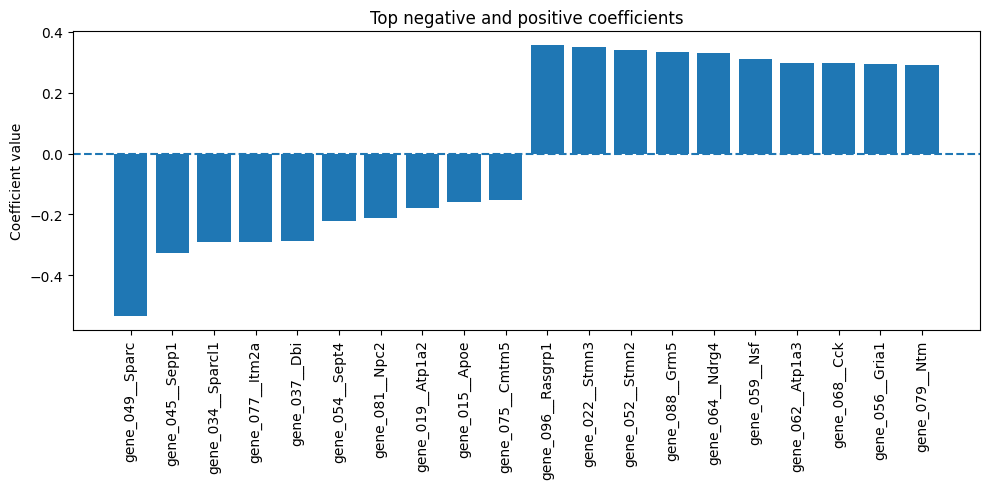

In [85]:
# Section 11 - Plot top coefficients

top_idx = np.concatenate([top_negative_idx, top_positive_idx])
top_names = [gene_columns[idx] for idx in top_idx]
top_values = w_selected[top_idx]

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_values)), top_values)
plt.xticks(range(len(top_values)), top_names, rotation=90)
plt.axhline(0, linestyle="--")
plt.ylabel("Coefficient value")
plt.title("Top negative and positive coefficients")
plt.tight_layout()
plt.show()


### Exercises for Section 11

**Exercise 11.1** Identify the top 5 positive coefficients.

**Exercise 11.2** Identify the top 5 negative coefficients.

**Exercise 11.3** What does a positive coefficient mean in this biological task?

**Exercise 11.4** What does a negative coefficient mean in this biological task?

**Exercise 11.5** Why should we avoid interpreting coefficients as causal effects?


In [ ]:
# Exercises for Section 11

# Ex 11.1
n_top = 5
sorted_indices = np.argsort(w_selected)

top_positive_idx = sorted_indices[-n_top:][::-1]

print("Top positive coefficients:")
for idx in top_positive_idx:
    print(gene_columns[idx], w_selected[idx])

# Ex 11.2
top_negative_idx = sorted_indices[:n_top]

# Ex 11.3
"""A positive coefficient means that higher expression of that gene pushes the model toward the neuronal class."""

# Ex 11.4
"""A negative coefficient means that higher expression of that gene pushes the model toward the non-neuronal class."""

# Ex 11.5
"""
We should avoid interpreting coefficients as causal effects because most models only capture associations in the observed data,
not true cause-and-effect relationships, and it is known that correlation does not imply causation.
There are always other hidden effect (confounders), that may influence both the feature and the target, creating misleading relationships.
Moreover, correlations and relationships can arise simply by coincidence due to the sampling process.
"""

## Section 12 — Final recap and submission

In this lab, we:

- loaded a real biological classification dataset
- represented gene expression data as a machine learning matrix
- explored class balance and gene expression distributions
- introduced linear classifiers
- used the sigmoid function to produce probabilities
- implemented logistic regression from scratch using NumPy
- optimized BCE loss with GD
- evaluated a binary classifier
- added L2 regularization
- inspected gene coefficients biologically

## Final reflection questions

1. What is the difference between a regression target and a classification label?
2. Why do we use the sigmoid function in logistic regression?
3. What does the output of logistic regression represent?
4. Why is BCE appropriate for binary classification?
5. Why can regularization improve generalization?
6. What does a positive gene coefficient mean in this model?
7. What is the difference between association and causality?



In [ ]:
# Final notes
# Use this cell for additional experiments or notes.
